# Figures — Anthropic / Eloundou

Replication and extension of key charts from the Anthropic Economic Index.

## Figure 1 · Share of Claude usage by Eloundou et al. exposure rating

Eloundou rows         : 19,265
Task penetration rows : 18,246

Claude-used tasks (penetration != 0) : 18,246

Diagnostics after merge:
  Total Claude-used tasks : 18,246
  Matched to beta      : 18,246
  Unmatched (no beta  ): 0  (0.0%)

Share of Claude-used tasks by beta bucket:
    Beta     Count     Share
  ----------------------------
     0.0     8,136     44.6%
     0.5     7,384     40.5%
     1.0     2,726     14.9%
   TOTAL    18,246    100.0%


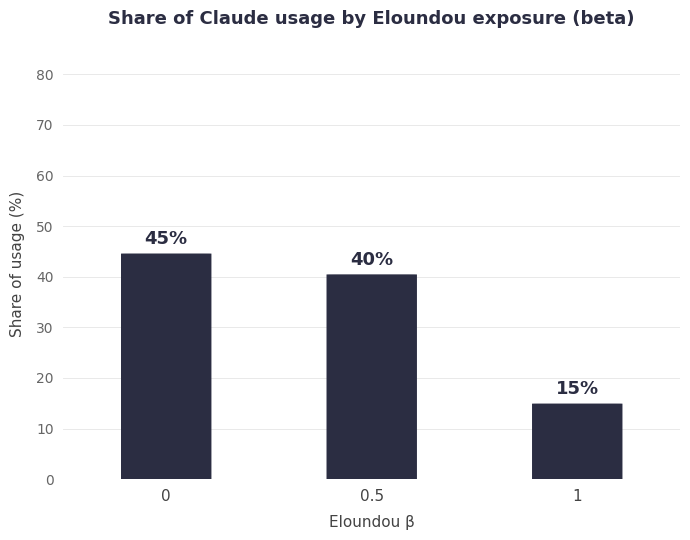


Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/fig1_claude_usage_beta.png


In [17]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

BASE             = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
ELOUNDOU_PATH    = BASE / "Eloundou_New" / "full_labelset_new.tsv"
PENETRATION_PATH = BASE / "Anthropic" / "task_penetration.csv"

# ── Switch between "beta" and "beta_new" (or any other column) here ──────────
BETA_COL = "beta"   # options: "beta", "beta_new"

OUTPUT_FIG = BASE / "Anthropic" / f"fig1_claude_usage_by_eloundou_{BETA_COL}.png"

# ── Load files ────────────────────────────────────────────────────────────────
df_eloundou = pd.read_csv(ELOUNDOU_PATH, sep="\t", low_memory=False)
df_penet    = pd.read_csv(PENETRATION_PATH)

print(f"Eloundou rows         : {len(df_eloundou):,}")
print(f"Task penetration rows : {len(df_penet):,}")

# ── Identify Claude-used tasks (penetration != 0) ─────────────────────────────
df_used = df_penet[df_penet["penetration"] != 0].copy()
print(f"\nClaude-used tasks (penetration != 0) : {len(df_used):,}")

# ── Keep one beta per unique task text in the Eloundou file ───────────────────
# (some tasks appear in multiple occupations — take the first occurrence, beta is task-level)
df_beta = (
    df_eloundou[["Task", BETA_COL]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)

# ── Normalise whitespace before merging ──────────────────────────────────────
df_used["task"] = df_used["task"].astype(str).str.strip()
df_beta["task"] = df_beta["task"].astype(str).str.strip()

# ── Merge Claude-used tasks with beta ─────────────────────────────────────────
df_merged = df_used.merge(df_beta, on="task", how="left")

n_total     = len(df_merged)
n_matched   = df_merged[BETA_COL].notna().sum()
n_unmatched = n_total - n_matched

print(f"\nDiagnostics after merge:")
print(f"  Total Claude-used tasks : {n_total:,}")
print(f"  Matched to {BETA_COL:<10}: {n_matched:,}")
print(f"  Unmatched (no {BETA_COL:<6}): {n_unmatched:,}  "
      f"({100 * n_unmatched / n_total:.1f}%)")

# ── Drop unmatched, group by beta bucket ──────────────────────────────────────
df_matched = df_merged.dropna(subset=[BETA_COL]).copy()
df_matched["beta_bucket"] = df_matched[BETA_COL].round(1)   # 0.0, 0.5, 1.0

bucket_counts = (
    df_matched.groupby("beta_bucket")
    .size()
    .reindex([0.0, 0.5, 1.0], fill_value=0)
    .rename("count")
)
bucket_pct = (bucket_counts / bucket_counts.sum() * 100).rename("pct")

print(f"\nShare of Claude-used tasks by {BETA_COL} bucket:")
print(f"  {'Beta':>6}  {'Count':>8}  {'Share':>8}")
print("  " + "-" * 28)
for b in [0.0, 0.5, 1.0]:
    print(f"  {b:>6.1f}  {int(bucket_counts[b]):>8,}  {bucket_pct[b]:>7.1f}%")
print(f"  {'TOTAL':>6}  {int(bucket_counts.sum()):>8,}  {'100.0%':>8}")

# ── Plot ──────────────────────────────────────────────────────────────────────
from pathlib import Path as _Path
REPORT_DIR = _Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)
OUTPUT_FIG = REPORT_DIR / f"fig1_claude_usage_{BETA_COL}.png"

NAVY = "#2B2D42"
LABELS = ["0", "0.5", "1"]
X      = np.array([0.0, 0.5, 1.0])
Y      = [bucket_pct[b] for b in X]

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

bars = ax.bar(X, Y, width=0.22, color=NAVY, zorder=3,
              edgecolor="white", linewidth=0.5)

for bar_rect in bars:
    import matplotlib.patches as mpatches
    bar_rect.set_linewidth(0)
    x0 = bar_rect.get_x()
    w  = bar_rect.get_width()
    h  = bar_rect.get_height()
    fancy = mpatches.FancyBboxPatch(
        (x0, 0), w, h,
        boxstyle=mpatches.BoxStyle.Round(pad=0, rounding_size=0.02),
        facecolor=NAVY, edgecolor="none", zorder=3)
    ax.add_patch(fancy)
    bar_rect.set_visible(False)

for i, val in enumerate(Y):
    ax.text(X[i], val + 1.0, f"{val:.0f}%",
            ha="center", va="bottom",
            fontsize=13, fontweight="bold", color="#2B2D42")

ax.set_title(
    f"Share of Claude usage by Eloundou exposure ({BETA_COL})",
    fontsize=13, fontweight="bold", pad=18, color="#2B2D42"
)
ax.set_xlabel(f"Eloundou \u03b2", fontsize=11, labelpad=8, color="#444444")
ax.set_ylabel("Share of usage (%)", fontsize=11, labelpad=8, color="#444444")

ax.set_xticks(X)
ax.set_xticklabels(LABELS, fontsize=11, color="#444444")
ax.set_xlim(-0.25, 1.25)

ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=10, colors="#666666")

ax.yaxis.grid(True, color="#E5E5E5", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", left=False)

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"\nFigure saved: {OUTPUT_FIG}")

# ── E0 tasks used by Claude (beta == 0, penetration != 0) ────────────────────
# e0_claude = df_matched[df_matched["beta"] == 0.0][["task", "penetration"]].copy()
# e0_claude = e0_claude.sort_values("penetration", ascending=False).reset_index(drop=True)
# e0_claude.index += 1

# print(f"E0 tasks used by Claude: {len(e0_claude):,}\n")
# print(e0_claude.to_string())


# Usage shares by Eloundou exposure

This notebook analyzes how observed Anthropic task usage is distributed across Eloundou exposure levels.

## Objective

The goal is to measure the share of observed task usage associated with tasks at different values of Eloundou exposure \( \beta \), using:

- Claude AI usage
- 1P API usage
- August 2025 data
- November 2025 data

The analysis is run separately for each of the four source files and then again on the pooled dataset.

## Data inputs

We use:

- `aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv`
- `aei_raw_1p_api_2025-08-04_to_2025-08-11.csv`
- `aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv`
- `aei_raw_1p_api_2025-11-13_to_2025-11-20 (1).csv`

We merge these usage counts to Eloundou task exposure scores from:

- `full_labelset_new.tsv`

using the selected exposure column, here:

- `beta`

## Task-level usage extraction

The notebook first extracts task-level counts from each source file.

For **Claude AI**:

- restrict to `platform_and_product == "Claude AI (Free and Pro)"`
- restrict to `geo_id == "GLOBAL"`
- when available, use the intersection:
  - `facet == "onet_task::use_case"`
  - `variable == "onet_task_use_case_count"`
  - keep only tasks ending in `::work`
- if the use-case split is not available, fall back to:
  - `facet == "onet_task"`
  - `variable == "onet_task_count"`

For **1P API**:

- restrict to `platform_and_product == "1P API"`
- restrict to `geo_id == "GLOBAL"`
- always use:
  - `facet == "onet_task"`
  - `variable == "onet_task_count"`

After extraction:

- task names are cleaned and lowercased
- missing values are dropped
- placeholder categories such as `not_classified` and `none` are removed
- duplicate task rows are aggregated to the task level

## Merge to Eloundou exposure

Each task-level usage table is merged to the Eloundou lookup using task text.

Each matched task is assigned to one of the three exposure buckets:

- \( \beta = 0 \)
- \( \beta = 0.5 \)
- \( \beta = 1 \)

The notebook reports both:

- matched vs unmatched task counts
- matched vs unmatched usage mass

This is important because the final exposure shares depend on the quality of the task matching.

## Computation of usage shares

For each source file, we sum raw usage counts by beta bucket:

$$
\text{RawCount}(\beta=b)
=
\sum_{t:\beta_t=b} \text{count}_t
$$

We then convert these into percentage shares:

$$
\text{Share}(\beta=b)
=
\frac{\text{RawCount}(\beta=b)}
{\sum_{b' \in \{0, 0.5, 1\}} \text{RawCount}(\beta=b')}
\times 100
$$

So the reported shares tell us what fraction of observed task usage falls into each Eloundou exposure level.

## Outputs

The notebook produces two plots.

### Plot 1: separate source files

A grouped bar chart compares the beta distribution of usage across:

- Claude AI, August
- 1P API, August
- Claude AI, November
- 1P API, November

This allows a direct comparison across platform and period.

### Plot 2: pooled usage

The notebook then pools raw counts across all four files:

$$
\text{CombinedRawCount}(\beta=b)
=
\sum_{s} \text{RawCount}_s(\beta=b)
$$

and computes a single normalized share distribution from the pooled totals.

This gives the overall distribution of observed task usage by beta level across all available usage sources.

## Interpretation

This notebook is not measuring penetration directly. Instead, it measures where observed task usage is concentrated across Eloundou exposure levels.

In other words, it answers:

- how much observed usage is attached to low-exposure tasks
- how much is attached to medium-exposure tasks
- how much is attached to high-exposure tasks

This provides a descriptive bridge between:

- observed real-world LLM usage
- the theoretical task exposure framework from Eloundou

Eloundou rows              : 19,265
Unique Eloundou tasks      : 17,992
Using beta column          : beta_new
Claude use-case filter     : work
API treatment              : all task-level occurrences

Claude AI · Aug 25  (aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv)
  Filter used                 : Claude fallback to all use cases via onet_task + onet_task_count
  Unique tasks after filter   : 2,616
  Tasks matched to beta_new  : 2,209
  Tasks unmatched             : 408
  Matched count mass          : 728,852.00
  Unmatched count mass        : 158,099.00
    β=0.0: raw_count=157,197.00   share=21.6%
    β=0.5: raw_count=111,390.00   share=15.3%
    β=1.0: raw_count=460,265.00   share=63.1%

1P API · Aug 25  (aei_raw_1p_api_2025-08-04_to_2025-08-11.csv)
  Filter used                 : API all task-level occurrences via onet_task + onet_task_count
  Unique tasks after filter   : 2,054
  Tasks matched to beta_new  : 1,739
  Tasks unmatched             : 316
  Matched count mass        

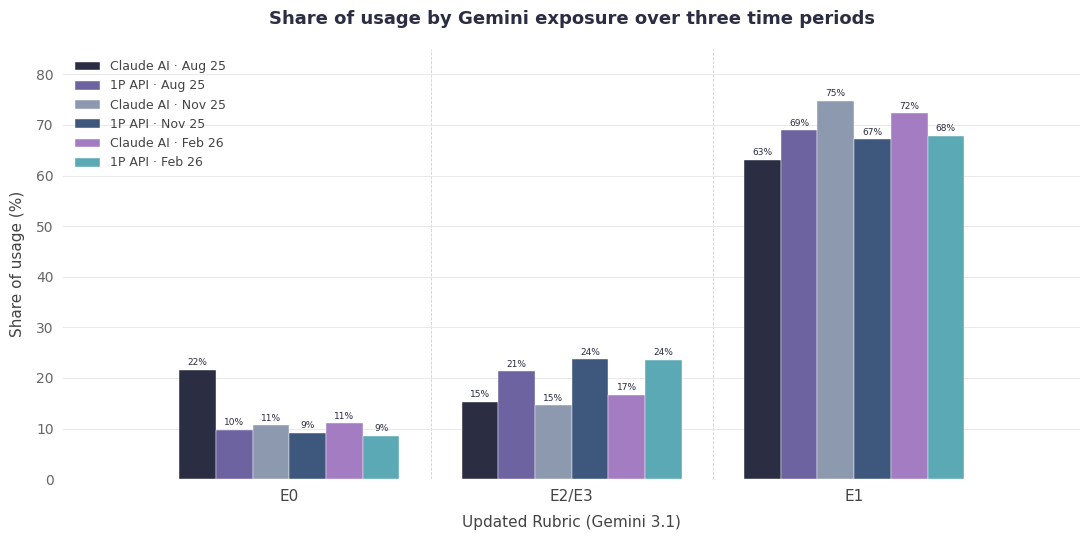

Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/fig_6files_beta_new_work.png


Pooled Claude usage share by Gemini β_new bucket:
    β=0.0: count=       232,623   share= 16.3%
    β=0.5: count=       220,301   share= 15.5%
    β=1.0: count=       972,478   share= 68.2%


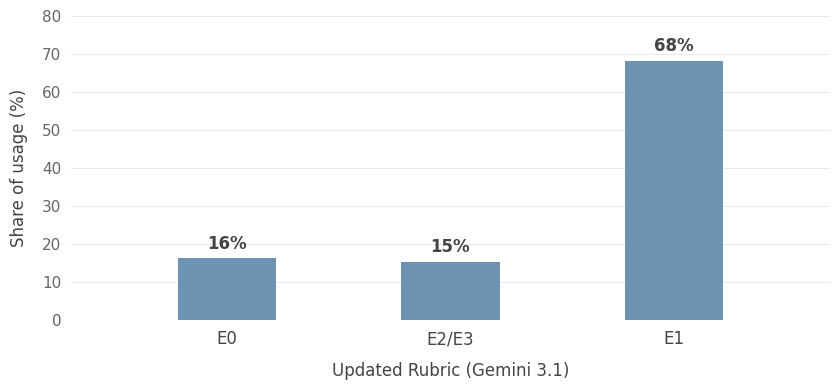


Figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/fig_claude_usage_gemini_beta_new.png


In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────
BASE = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
ELOUNDOU_PATH = BASE / "Eloundou_New" / "full_labelset_new.tsv"

BETA_COL = "beta_new"
GEO_ID   = "GLOBAL"
USE_CASE = "work"   # used only for Claude AI
OUTPUT_FIG = BASE / "Anthropic" / f"fig_4files_{BETA_COL}_{USE_CASE}_corrected.png"
OUTPUT_FIG_COMBINED = BASE / "Anthropic" / f"fig_combined_{BETA_COL}_{USE_CASE}_corrected.png"

# ── Six source files (Aug 2025, Nov 2025, Feb 2026) ──────────────────
SOURCES = [
    {
        "label":  "Claude AI · Aug 25",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv",
        "period": "Aug 2025",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Aug 25",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2025-08-04_to_2025-08-11.csv",
        "period": "Aug 2025",
        "kind":   "api",
    },
    {
        "label":  "Claude AI · Nov 25",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv",
        "period": "Nov 2025",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Nov 25",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2025-11-13_to_2025-11-20 (1).csv",
        "period": "Nov 2025",
        "kind":   "api",
    },
    {
        "label":  "Claude AI · Feb 26",
        "path":   BASE / "Anthropic" / "aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv",
        "period": "Feb 2026",
        "kind":   "claude",
    },
    {
        "label":  "1P API · Feb 26",
        "path":   BASE / "Anthropic" / "aei_raw_1p_api_2026-02-05_to_2026-02-12.csv",
        "period": "Feb 2026",
        "kind":   "api",
    },
]

# ── Eloundou beta lookup ──────────────────────────────────────────────
df_eloundou = pd.read_csv(ELOUNDOU_PATH, sep="\t", low_memory=False)
df_beta = (
    df_eloundou[["Task", BETA_COL]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)
df_beta["task"] = df_beta["task"].astype(str).str.strip().str.lower()

print(f"Eloundou rows              : {len(df_eloundou):,}")
print(f"Unique Eloundou tasks      : {len(df_beta):,}")
print(f"Using beta column          : {BETA_COL}")
print(f"Claude use-case filter     : {USE_CASE}")
print(f"API treatment              : all task-level occurrences\n")


# ── Helper: load usage rows correctly as COUNTS ───────────────────────
def extract_task_counts(path, geo_id, source_kind, use_case):
    df = pd.read_csv(path)

    if "platform_and_product" in df.columns:
        if source_kind == "claude":
            df = df[df["platform_and_product"].astype(str).str.startswith("Claude AI")].copy()
        elif source_kind == "api":
            df = df[df["platform_and_product"] == "1P API"].copy()

    if "geo_id" in df.columns:
        df = df[df["geo_id"] == geo_id].copy()

    if source_kind == "claude":
        # Prefer work-only if the intersection facet exists
        has_uc = (df["facet"] == "onet_task::use_case").any()
        if has_uc:
            out = df[
                (df["facet"] == "onet_task::use_case") &
                (df["variable"] == "onet_task_use_case_count") &
                (df["cluster_name"].astype(str).str.endswith(f"::{use_case}"))
            ].copy()

            out["task"] = out["cluster_name"].astype(str).str.rsplit("::", n=1).str[0]
            out = out.rename(columns={"value": "count"})[["task", "count"]]
            note = f"Claude filtered to use_case={use_case} via onet_task::use_case + onet_task_use_case_count"
        else:
            out = df[
                (df["facet"] == "onet_task") &
                (df["variable"] == "onet_task_count")
            ].copy()

            out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
            note = "Claude fallback to all use cases via onet_task + onet_task_count"
    else:
        # API always uses all task-level occurrences, as requested
        out = df[
            (df["facet"] == "onet_task") &
            (df["variable"] == "onet_task_count")
        ].copy()

        out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
        note = "API all task-level occurrences via onet_task + onet_task_count"

    out["task"] = out["task"].astype(str).str.strip().str.lower()
    out["count"] = pd.to_numeric(out["count"], errors="coerce")
    out = out.dropna(subset=["task", "count"]).copy()

    # Drop privacy / placeholder categories if present
    out = out[~out["task"].isin(["not_classified", "none"])].copy()

    # Aggregate in case a task appears more than once after filtering
    out = out.groupby("task", as_index=False)["count"].sum()

    return out, note


# ── Helper: merge to beta and compute beta-bucket shares ──────────────
def compute_beta_shares_from_counts(task_counts, beta_lookup, beta_col):
    df_m = task_counts.merge(beta_lookup, on="task", how="left")

    matched_tasks = df_m[beta_col].notna().sum()
    unmatched_tasks = df_m[beta_col].isna().sum()
    matched_count_mass = df_m.loc[df_m[beta_col].notna(), "count"].sum()
    unmatched_count_mass = df_m.loc[df_m[beta_col].isna(), "count"].sum()

    df_m = df_m.dropna(subset=[beta_col]).copy()
    df_m["beta_bucket"] = pd.to_numeric(df_m[beta_col], errors="coerce").round(1)
    df_m = df_m[df_m["beta_bucket"].isin([0.0, 0.5, 1.0])].copy()

    raw_counts = (
        df_m.groupby("beta_bucket")["count"]
        .sum()
        .reindex([0.0, 0.5, 1.0], fill_value=0.0)
    )

    share = raw_counts / raw_counts.sum() * 100 if raw_counts.sum() > 0 else raw_counts.copy()

    diagnostics = {
        "tasks_total": len(task_counts),
        "tasks_matched": int(matched_tasks),
        "tasks_unmatched": int(unmatched_tasks),
        "count_mass_matched": float(matched_count_mass),
        "count_mass_unmatched": float(unmatched_count_mass),
        "raw_counts": raw_counts,
        "share": share,
    }
    return diagnostics


# ── Compute for all six files ─────────────────────────────────────────
for src in SOURCES:
    print(f"{src['label']}  ({src['path'].name})")
    task_counts, note = extract_task_counts(src["path"], GEO_ID, src["kind"], USE_CASE)
    diag = compute_beta_shares_from_counts(task_counts, df_beta, BETA_COL)

    src["note"] = note
    src["task_counts"] = task_counts
    src["diag"] = diag
    src["share"] = diag["share"]
    src["raw_counts"] = diag["raw_counts"]

    print(f"  Filter used                 : {note}")
    print(f"  Unique tasks after filter   : {diag['tasks_total']:,}")
    print(f"  Tasks matched to {BETA_COL:<10}: {diag['tasks_matched']:,}")
    print(f"  Tasks unmatched             : {diag['tasks_unmatched']:,}")
    print(f"  Matched count mass          : {diag['count_mass_matched']:,.2f}")
    print(f"  Unmatched count mass        : {diag['count_mass_unmatched']:,.2f}")
    for b in [0.0, 0.5, 1.0]:
        print(
            f"    β={b:.1f}: raw_count={diag['raw_counts'][b]:,.2f}   share={diag['share'][b]:.1f}%"
        )
    print()


# ── Paths & palette ────────────────────────────────────────────────────
from pathlib import Path as _Path
import matplotlib.patches as mpatches

REPORT_DIR = _Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)
OUTPUT_FIG          = REPORT_DIR / f"fig_6files_{BETA_COL}_{USE_CASE}.png"
OUTPUT_FIG_COMBINED = REPORT_DIR / f"fig_combined_{BETA_COL}_{USE_CASE}.png"

PALETTE = ["#2B2D42", "#6C63A0", "#8D99AE", "#3E577C", "#A47CC2", "#5BA9B5"]
HATCH   = [None] * 6

X = np.array([0.0, 0.5, 1.0])
width = 0.065

# Drop sources with no matched usage mass so the grouped bars do not reserve
# an empty visual slot (e.g., a missing Claude use-case file/facet).
_active = [
    (i, src) for i, src in enumerate(SOURCES)
    if src["raw_counts"].sum() > 0
]
n_active = len(_active)
offsets = np.linspace(-(n_active - 1) * width / 2, (n_active - 1) * width / 2, n_active)

if n_active < len(SOURCES):
    dropped = ", ".join(src["label"] for src in SOURCES if src["raw_counts"].sum() <= 0)
    print(f"Dropped source(s) with no matched usage mass from plot: {dropped}")

# ── Plot 1: active files side by side ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

for j, (i, src) in enumerate(_active):
    bars = ax.bar(
        X + offsets[j], src["share"].values, width=width,
        color=PALETTE[i], label=src["label"], zorder=3,
        edgecolor="white", linewidth=0.3,
        hatch=HATCH[i],
    )
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                    f"{h:.0f}%", ha="center", va="bottom",
                    fontsize=6.5, color="#2B2D42")

for xv in [0.25, 0.75]:
    ax.axvline(xv, color="#D0D0D0", linewidth=0.6, linestyle="--", zorder=0)

ax.set_title(
    f"Share of usage by Gemini exposure over three time periods",
    fontsize=13, fontweight="bold", pad=18, color="#2B2D42",
)
ax.set_xlabel("Updated Rubric (Gemini 3.1)", fontsize=11, labelpad=8, color="#444444")
ax.set_ylabel("Share of usage (%)", fontsize=11, labelpad=8, color="#444444")

ax.set_xticks(X)
ax.set_xticklabels(["E0", "E2/E3", "E1"], fontsize=11, color="#444444")
ax.set_xlim(-0.4, 1.4)
ax.set_ylim(0, 85)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=10, colors="#666666")

ax.yaxis.grid(True, color="#E5E5E5", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", left=False)

ax.legend(fontsize=9, loc="upper left", frameon=False, labelcolor="#444444")

plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure saved: {OUTPUT_FIG}\n")


# ── Plot 2: Share of Claude usage by Gemini exposure rating ──────────
# Reproduces the Anthropic Economic Index figure ("Share of Claude usage
# by Eloundou et al. exposure rating") but using the updated Gemini rubric
# (beta_new) instead of Eloundou beta.
#
# Pools raw Claude AI usage counts across the three AEI release windows
# (Aug 2025, Nov 2025, Feb 2026) and groups by beta_new bucket.

_claude_pooled = pd.Series(0.0, index=[0.0, 0.5, 1.0])
for src in SOURCES:
    if src["kind"] != "claude":
        continue
    _claude_pooled = _claude_pooled.add(src["raw_counts"], fill_value=0.0)

_claude_share = _claude_pooled / _claude_pooled.sum() * 100

print("\nPooled Claude usage share by Gemini \u03b2_new bucket:")
for _b in [0.0, 0.5, 1.0]:
    print(f"    \u03b2={_b:.1f}: count={_claude_pooled[_b]:>14,.0f}   share={_claude_share[_b]:>5.1f}%")

# styled to match the comparison-plot reference image
BAR_COLOR  = "#6E93B2"
GRID_COLOR = "#E5E5E5"
TEXT_COLOR = "#444444"
TICK_COLOR = "#666666"

fig, ax = plt.subplots(figsize=(8.5, 4))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

X = np.array([0.0, 0.5, 1.0])
width = 0.22
_vals = _claude_share.values

ax.bar(X, _vals, width=width, color=BAR_COLOR, zorder=3,
       edgecolor="none", linewidth=0)

for xi, vi in zip(X, _vals):
    ax.text(xi, vi + 1.5, f"{vi:.0f}%",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold", color=TEXT_COLOR)

ax.set_xlabel("Updated Rubric (Gemini 3.1)", fontsize=12, labelpad=10, color=TEXT_COLOR)
ax.set_ylabel("Share of usage (%)", fontsize=12, labelpad=10, color=TEXT_COLOR)

ax.set_xticks(X)
ax.set_xticklabels(["E0", "E2/E3", "E1"], fontsize=12, color=TEXT_COLOR)
ax.set_xlim(-0.35, 1.35)

_ymax = max(70, int(np.ceil((_vals.max() + 5) / 10) * 10))
ax.set_ylim(0, _ymax)
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.tick_params(axis="y", labelsize=11, colors=TICK_COLOR)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", bottom=False)
ax.tick_params(axis="y", left=False)

plt.tight_layout()
OUTPUT_FIG_GEMINI = REPORT_DIR / f"fig_claude_usage_gemini_{BETA_COL}.png"
plt.savefig(OUTPUT_FIG_GEMINI, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"\nFigure saved: {OUTPUT_FIG_GEMINI}")

## Bubble Plot · Potential vs. Current AI Exposure by Industry

Each bubble is one **NAICS 2-digit sector** (Manufacturing, Finance & Insurance, Information & Tech, …), with companies assigned to a sector by the modal `naics_code` of their employee rows.

| Axis / encoding | Metric | Meaning |
|-----------------|--------|---------|
| X | `time_based_score` | Gemini **potential** — π-weighted mean of `beta_new`, employee-weighted across the sector |
| Y | `observed_penetration_score` | Anthropic **current** — π-weighted mean of `penetration_beta_new`, employee-weighted across the sector |
| Bubble size | Headline opportunity ($) | Gemini-rubric automatable wage mass in the sector at the **50 %** headline scenario: `0.50 × Σ_{occ, task in E1 ∪ E2/E3} (n_workers_{sector, occ} × avg_wage_{sector, occ} × π_norm)` |

Each bubble is labelled `Industry` on the first line and `Gemini 0.xx (Anthropic 0.xx)` on the second — Gemini potential with Anthropic current in parentheses, both expressed as raw score values. Labels sit **outside** their bubble with a thin leader arrow pointing to the data point. Axes are padded so no bubble is clipped, while axis ticks remain formatted as percentages for readability. The 50 % rate matches the headline Gemini automation scenario used in `1 - sp500_new_scores_task_analysis`, so bubble size represents the headline automatable dollar mass per industry.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from pathlib import Path
from matplotlib.lines import Line2D

# ── Paths ─────────────────────────────────────────────────────────────
BASE           = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
OCC_FILE       = BASE / "Eloundou_New" / "occ_level_new.csv"
SP500_FILE     = BASE / "data" / "sp500_company_data.parquet"
TASK_TIME_PATH = BASE / "data" / "job_task_time_distribution_30_0.csv"
EXPOSURE_PATH  = BASE / "Eloundou_New" / "full_labelset_new.tsv"
REPORT_DIR     = BASE / "Report images"
REPORT_DIR.mkdir(exist_ok=True)
OUTPUT_FIG      = REPORT_DIR / "bubble_industry_gemini_vs_anthropic.png"
OUTPUT_FIG_NOBG = REPORT_DIR / "bubble_industry_gemini_vs_anthropic_nobg.png"

# ── Headline Gemini automation rate (matches notebook 1 summary scenario) ──
LONG_TERM_RATE = 0.50

# ── NAICS 2-digit sector labels (same mapping as notebook 1.1) ───────
NAICS_SECTORS = {
    "11": "Agriculture", "21": "Mining & Oil/Gas", "22": "Utilities",
    "23": "Construction", "31": "Manufacturing", "32": "Manufacturing",
    "33": "Manufacturing", "42": "Wholesale Trade",
    "44": "Retail Trade", "45": "Retail Trade",
    "48": "Transportation", "49": "Transportation",
    "51": "Information & Tech", "52": "Finance & Insurance",
    "53": "Real Estate", "54": "Professional Services",
    "55": "Mgmt of Companies", "56": "Admin & Support",
    "61": "Education", "62": "Healthcare",
    "71": "Arts & Entertainment", "72": "Accommodation & Food",
    "81": "Other Services", "92": "Public Admin",
}

# ── 1. Load occ-level scores ──────────────────────────────────────────
df_occ = pd.read_csv(OCC_FILE, skipinitialspace=True)
df_occ.columns = df_occ.columns.str.strip()
df_occ["O*NET-SOC Code"] = df_occ["O*NET-SOC Code"].astype(str).str.strip()

# ── 2. Load SP500 employee rows (with NAICS, wage, weight) ────────────
_emp = pq.read_table(
    SP500_FILE,
    columns=["ticker", "onet_code", "weight", "salary", "naics_code"],
).to_pandas()
_emp["onet_code"] = _emp["onet_code"].astype(str).str.strip()
_emp = _emp[_emp["onet_code"].str.match(r"^\d{2}-")].copy()
_emp["weight"] = _emp["weight"].fillna(1.0)

# One NAICS per company (modal), then 2-digit → sector label
_naics_rows = _emp.dropna(subset=["ticker", "naics_code"])[["ticker", "naics_code"]]
naics_per_company = (
    _naics_rows.groupby("ticker")["naics_code"]
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else np.nan)
    .reset_index()
)
naics_per_company["naics2"] = naics_per_company["naics_code"].astype(str).str[:2]
naics_per_company["sector"] = naics_per_company["naics2"].map(NAICS_SECTORS)
_emp = _emp.merge(naics_per_company[["ticker", "sector"]], on="ticker", how="left")
_emp = _emp.dropna(subset=["sector"]).copy()

# Impute missing salaries from the occupation-level weighted mean
_with_wage = _emp.dropna(subset=["salary"])
occ_wage = (
    _with_wage.groupby("onet_code")
    .apply(lambda g: np.average(g["salary"], weights=g["weight"]))
    .rename("_occ_wage").reset_index()
)
_emp = _emp.merge(occ_wage, on="onet_code", how="left")
_emp["salary"] = _emp["salary"].fillna(_emp["_occ_wage"])

w_total_sp500 = _emp["weight"].sum()
print(f"SP500 weighted employees (with sector): {w_total_sp500:,.0f}")
print(f"Unique sectors:                         {_emp['sector'].nunique()}")
print(f"Unique occupations:                     {_emp['onet_code'].nunique():,}")

# ── 3. Per-(sector, occupation) worker count & avg wage ──────────────
so_agg = (
    _emp.dropna(subset=["salary"])
    .groupby(["sector", "onet_code"])
    .apply(lambda g: pd.Series({
        "n_workers": g["weight"].sum(),
        "avg_wage":  np.average(g["salary"], weights=g["weight"]),
    }))
    .reset_index()
    .rename(columns={"onet_code": "occ_id"})
)

# ── 4. Task-time distribution (π) ────────────────────────────────────
df_pi = pd.read_csv(TASK_TIME_PATH)
_pi_occ  = next((c for c in ["O*NET-SOC Code", "onet_code", "onet", "soc_code"] if c in df_pi.columns), None)
_pi_task = next((c for c in ["Task ID", "task_id", "TaskID"] if c in df_pi.columns), None)
_pi_val  = next((c for c in ["pi", "Pi", "task_share", "time_share"] if c in df_pi.columns), None)
df_pi = df_pi.rename(columns={_pi_occ: "occ_id", _pi_task: "task_id", _pi_val: "pi"})
df_pi = df_pi[["occ_id", "task_id", "pi"]]

# ── 5. Task-level exposure labels ────────────────────────────────────
df_exp = pd.read_csv(EXPOSURE_PATH, sep="\t")
_e_occ   = next((c for c in ["O*NET-SOC Code", "onet_code", "onet", "soc_code"] if c in df_exp.columns), None)
_e_task  = next((c for c in ["Task ID", "task_id", "TaskID"] if c in df_exp.columns), None)
_e_label = next((c for c in ["new_labels", "exposure_label", "label", "gpt4_exposure", "human_exposure_agg"] if c in df_exp.columns), None)
df_exp = df_exp[[_e_occ, _e_task, _e_label]].copy()
df_exp.columns = ["occ_id", "task_id", "exposure_label"]

# ── 6. Build (sector × occ × task) economic value & long-term opportunity ──
df_ot = (
    df_pi.merge(df_exp, on=["occ_id", "task_id"], how="left")
         .dropna(subset=["exposure_label"])
         .copy()
)
# renormalise π within labelled tasks per occupation (same as notebook 1)
df_ot["pi_norm"] = df_ot.groupby("occ_id")["pi"].transform(lambda x: x / x.sum())

df_sot = so_agg.merge(df_ot, on="occ_id", how="inner")
df_sot["task_value"] = df_sot["n_workers"] * df_sot["avg_wage"] * df_sot["pi_norm"]

BUCKET_MAP = {"E0": "E0", "E1": "E1", "E2": "E2/E3", "E3": "E2/E3"}
df_sot["bucket"] = df_sot["exposure_label"].map(BUCKET_MAP)

# Headline Gemini opportunity: 50 % of E1 + E2/E3 wage mass, per sector.
opp_sector = (
    df_sot[df_sot["bucket"].isin(["E1", "E2/E3"])]
    .groupby("sector")["task_value"].sum()
    * LONG_TERM_RATE
).rename("opportunity")

# ── 7. Per-sector employee-weighted Gemini + Anthropic scores ────────
df_occ_scores = (
    df_occ[["O*NET-SOC Code", "time_based_score", "observed_penetration_score"]]
    .drop_duplicates(subset=["O*NET-SOC Code"])
)
_emp_scored = _emp.merge(
    df_occ_scores.rename(columns={"O*NET-SOC Code": "onet_code"}),
    on="onet_code", how="left",
)

def _wavg(grp, col):
    mask = grp[col].notna() & (grp["weight"] > 0)
    w = grp.loc[mask, "weight"]
    v = grp.loc[mask, col]
    return (v * w).sum() / w.sum() if w.sum() > 0 else np.nan

sector_rows = []
for sector, grp in _emp_scored.groupby("sector"):
    sector_rows.append({
        "sector":      sector,
        "gemini":      _wavg(grp, "time_based_score"),
        "anthropic":   _wavg(grp, "observed_penetration_score"),
        "n_employees": grp["weight"].sum(),
    })

df_sector = pd.DataFrame(sector_rows).merge(opp_sector.reset_index(), on="sector", how="left")
df_sector["opportunity"] = df_sector["opportunity"].fillna(0.0)
df_sector = df_sector.dropna(subset=["gemini", "anthropic"]).reset_index(drop=True)

print(f"\nSectors plotted: {len(df_sector)}")
_disp = df_sector[["sector", "gemini", "anthropic", "opportunity", "n_employees"]].copy()
_disp["opportunity"] = _disp["opportunity"].apply(lambda x: f"${x:,.0f}")
_disp["n_employees"] = _disp["n_employees"].apply(lambda x: f"{x:,.0f}")
print(_disp.to_string(index=False))

# ── 8. Bubble plot ───────────────────────────────────────────────────
from matplotlib.ticker import FuncFormatter, MultipleLocator
from matplotlib.lines import Line2D as _L2D

DARK_BLUE  = "#3E577C"
LIGHT_BLUE = "#8FB3E8"
GRID_COLOR = "#D0D0D0"
TEXT_COLOR = "#4A4A4A"

df_sector["gem_label"] = df_sector["gemini"]
df_sector["ant_label"] = df_sector["anthropic"]

# ── Bubble sizes ──────────────────────────────────────────────────────
_opp = df_sector["opportunity"].to_numpy(dtype=float)
_opp_max = _opp.max() if _opp.max() > 0 else 1.0
_opp_min = _opp.min()
_SMIN, _SMAX = 300.0, 5500.0
if _opp_max > _opp_min:
    sizes = _SMIN + (_opp - _opp_min) / (_opp_max - _opp_min) * (_SMAX - _SMIN)
else:
    sizes = np.full_like(_opp, (_SMIN + _SMAX) / 2)

# ── Axis limits: X generous, Y hard-capped at 45% ────────────────────
_x_max = df_sector["gemini"].max()
_y_cap = 0.45                          # hard Y ceiling
_xlim_low  = -0.02
_xlim_high = _x_max * 1.30
_ylim_low  = -0.01
_ylim_high = _y_cap

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_alpha(0)
ax.set_facecolor("none")
ax.patch.set_alpha(0)
ax.set_xlim(_xlim_low, _xlim_high)
ax.set_ylim(_ylim_low, _ylim_high)

ax.scatter(
    df_sector["gemini"], df_sector["anthropic"],
    s=sizes,
    facecolors=LIGHT_BLUE, edgecolors=DARK_BLUE,
    linewidths=1.4, alpha=0.55, zorder=3, clip_on=False,
)

# ── 8a. Leader-arrow labels — tidy two-sided layout ──────────────────
# Split labels left/right of the cloud, then stack them vertically. This keeps
# labels off the bubbles and avoids the criss-cross pattern from radial labels.
_xspan = _xlim_high - _xlim_low
_yspan = _ylim_high - _ylim_low
_x_mid = df_sector["gemini"].median()

labels = []
for _, row in df_sector.iterrows():
    x, y = row["gemini"], row["anthropic"]
    side = "left" if x <= _x_mid else "right"
    labels.append({
        "x": x, "y": y,
        "side": side,
        "sector": row["sector"],
        "gem": row["gem_label"],
        "ant": row["ant_label"],
    })

# Leave the top-left corner for the legend; start left-side labels below it.
_y_slots = {
    "left":  np.linspace(_ylim_low + 0.035, _ylim_high - 0.115,
                         max(1, sum(la["side"] == "left" for la in labels))),
    "right": np.linspace(_ylim_low + 0.035, _ylim_high - 0.025,
                         max(1, sum(la["side"] == "right" for la in labels))),
}

for side in ("left", "right"):
    side_labels = sorted([la for la in labels if la["side"] == side], key=lambda d: d["y"])
    for la, ly in zip(side_labels, _y_slots[side]):
        if side == "left":
            la["lx"] = max(_xlim_low + 0.11 * _xspan, la["x"] - 0.115 * _xspan)
            la["ha"] = "center"
        else:
            la["lx"] = min(_xlim_high - 0.10 * _xspan, la["x"] + 0.105 * _xspan)
            la["ha"] = "center"
        la["ly"] = float(ly)

for la in labels:
    ax.annotate(
        f"{la['sector']}\nGemini {la['gem']:.2f}  (Anthropic {la['ant']:.2f})",
        xy=(la["x"], la["y"]),
        xytext=(la["lx"], la["ly"]),
        ha=la["ha"], va="center",
        fontsize=11.1, color="#2B2D42",
        arrowprops=dict(arrowstyle="-", color=DARK_BLUE, lw=0.6, alpha=0.5,
                        shrinkA=4, shrinkB=6,
                        connectionstyle="arc3,rad=0.08"),
        bbox=dict(boxstyle="round,pad=0.20", fc="none", ec="#C0C0C0",
                  lw=0.45, alpha=0.0),
        zorder=6,
    )

# ── Axes styling ──────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _p: f"{v*100:.0f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _p: f"{v*100:.0f}%"))
ax.xaxis.set_major_locator(MultipleLocator(0.10))
ax.yaxis.set_major_locator(MultipleLocator(0.05))

ax.set_xlabel("Gemini potential exposure  (π-weighted β_new)",
              fontsize=11, color=TEXT_COLOR, labelpad=9)
ax.set_ylabel("Anthropic current penetration  (π-weighted penetration_beta_new)",
              fontsize=11, color=TEXT_COLOR, labelpad=9)

ax.grid(True, linestyle=":", linewidth=0.7, color=GRID_COLOR, zorder=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID_COLOR)

# Identity line — only within visible range, labelled directly on the line
_id_x = [max(_xlim_low, _ylim_low), min(_xlim_high, _ylim_high)]
ax.plot(_id_x, _id_x, color="#A0A0A0", linestyle="--", linewidth=0.9, zorder=1)
# Keep the diagonal as an unlabeled visual reference.

# ── 8b. Single combined legend — top-left ────────────────────────────
# Only smallest and largest bubbles; no ghost-at-origin issue with Line2D.
def _size_for(val):
    if _opp_max > _opp_min:
        return _SMIN + (val - _opp_min) / (_opp_max - _opp_min) * (_SMAX - _SMIN)
    return (_SMIN + _SMAX) / 2

_v_small = _opp[_opp > 0].min() if (_opp > 0).any() else _opp_min
_v_large = _opp_max

_h_small = _L2D([0], [0], marker="o", linestyle="None",
                markersize=float(np.sqrt(_size_for(_v_small))) * 0.52,
                markerfacecolor=LIGHT_BLUE, markeredgecolor=DARK_BLUE,
                markeredgewidth=1.1, alpha=0.75,
                label=f"Smallest opportunity  (${_v_small/1e9:,.1f} B)")

_h_large = _L2D([0], [0], marker="o", linestyle="None",
                markersize=float(np.sqrt(_size_for(_v_large))) * 0.52,
                markerfacecolor=LIGHT_BLUE, markeredgecolor=DARK_BLUE,
                markeredgewidth=1.1, alpha=0.75,
                label=f"Largest opportunity  (${_v_large/1e9:,.1f} B)")

_legend = ax.legend(
    handles=[_h_small, _h_large],
    title=f"Bubble size = exposed wage bill (considering {int(LONG_TERM_RATE*100)}% efficiency gain)",
    loc="upper left", frameon=True,
    framealpha=0.0, edgecolor="#C0C0C0",
    labelspacing=1.8, borderpad=1.35,
    fontsize=9, title_fontsize=9,
    handletextpad=2.0, handleheight=3.0,
    columnspacing=3.6, ncol=2,
)
_legend.get_frame().set_facecolor("none")

plt.tight_layout()
plt.savefig(OUTPUT_FIG,      dpi=200, bbox_inches="tight", transparent=True, facecolor="none", edgecolor="none")
plt.savefig(OUTPUT_FIG_NOBG, dpi=200, bbox_inches="tight", transparent=True, facecolor="none", edgecolor="none")
plt.show()

print(f"\nFigure saved: {OUTPUT_FIG}")
print(f"Figure saved: {OUTPUT_FIG_NOBG}")

## Scatter Plots · AI Exposure vs. BLS Projected Employment Change

Two panels per figure — **left: OLS (unweighted)**, **right: WLS (employee-weighted)**.

| Figure | X-axis metric |
|--------|---------------|
| Figure A | `time_based_score` (theoretical, pi-weighted β) |
| Figure B | `observed_penetration_score` (observed penetration) |

SP500 weighted employees total:  26,493,389
Matched to occ scores (soc6):    24,323,989 (91.8%)
Occupations after BLS merge:     768 / 798
Weighted empl. after BLS merge:  24,116,441 (91.0%)


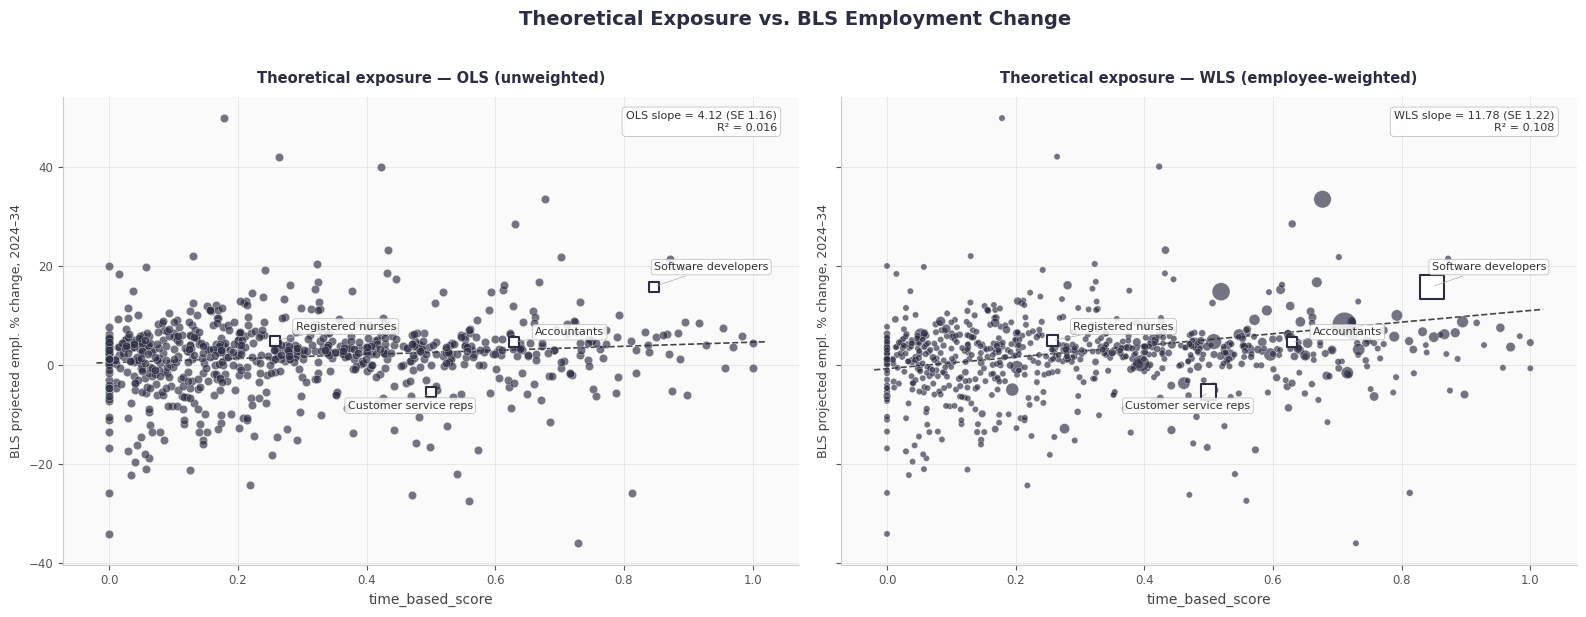

Figure A saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/scatter_theoretical_panel.png  (n = 768, 768)


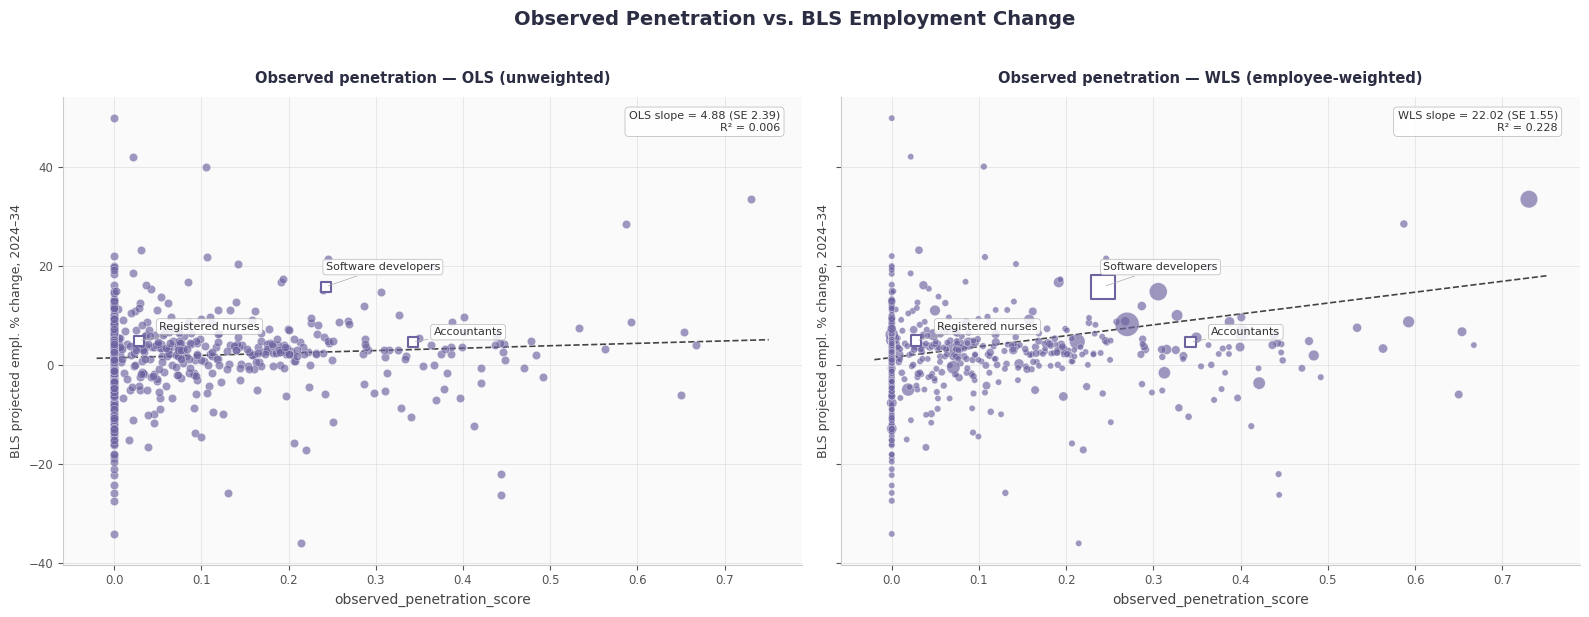

Figure B saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/scatter_observed_panel.png  (n = 688, 688)


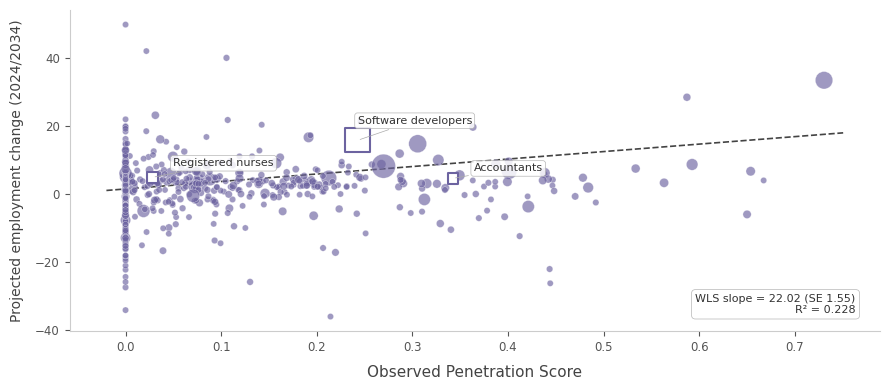

Solo figure saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/scatter_observed_wls_solo.png


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import statsmodels.api as sm
from scipy import stats as sp_stats
from pathlib import Path

BASE       = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")
OCC_FILE   = BASE / "Eloundou_New" / "occ_level_new.csv"
BLS_FILE   = BASE / "data" / "Employment Projections.csv"
SP500_FILE = BASE / "data" / "sp500_company_data.parquet"

# ── 1. Load occ-level scores + weighted emp counts at detailed level ──
df_occ = pd.read_csv(OCC_FILE, skipinitialspace=True)
df_occ.columns = df_occ.columns.str.strip()
df_occ["O*NET-SOC Code"] = df_occ["O*NET-SOC Code"].astype(str).str.strip()
df_occ["soc6"] = df_occ["O*NET-SOC Code"].str[:7]

# Weighted employee counts per detailed O*NET code
_emp_sc = pq.read_table(SP500_FILE, columns=["onet_code", "weight"]).to_pandas()
_emp_sc["onet_code"] = _emp_sc["onet_code"].astype(str).str.strip()
_emp_sc["weight"] = _emp_sc["weight"].fillna(1.0)
_emp_sc = _emp_sc[_emp_sc["onet_code"].str.match(r"^\d{2}-")]
w_total_sp500 = _emp_sc["weight"].sum()

emp_detail = (
    _emp_sc.groupby("onet_code")["weight"]
    .sum().rename("n_emp_detail")
    .reset_index().rename(columns={"onet_code": "O*NET-SOC Code"})
)

# Merge weighted counts onto detailed occ scores
df_occ = df_occ.merge(emp_detail, on="O*NET-SOC Code", how="left")
df_occ["n_emp_detail"] = df_occ["n_emp_detail"].fillna(0)

# Aggregate to soc6 using employee-weighted averages
def _wavg_soc6(grp, col):
    mask = grp[col].notna() & (grp["n_emp_detail"] > 0)
    w = grp.loc[mask, "n_emp_detail"]
    v = grp.loc[mask, col]
    return (v * w).sum() / w.sum() if w.sum() > 0 else np.nan

soc6_records = []
for soc6, grp in df_occ.groupby("soc6"):
    soc6_records.append({
        "soc6": soc6,
        "time_based_score":            _wavg_soc6(grp, "time_based_score"),
        "observed_penetration_score":  _wavg_soc6(grp, "observed_penetration_score"),
        "dv_rating_new":               _wavg_soc6(grp, "dv_rating_new"),
        "n_employees":                 grp["n_emp_detail"].sum(),
        "Title":                       grp["Title"].dropna().iloc[0] if grp["Title"].notna().any() else soc6,
    })

occ_agg = pd.DataFrame(soc6_records)
occ_agg["exposure_theo"] = occ_agg["time_based_score"].fillna(occ_agg["dv_rating_new"])
occ_agg["exposure_obs"]  = occ_agg["observed_penetration_score"]
occ_agg["Title"] = occ_agg["Title"].astype(str).str.strip()

w_in_occ_agg = occ_agg["n_employees"].sum()
print(f"SP500 weighted employees total:  {w_total_sp500:,.0f}")
print(f"Matched to occ scores (soc6):    {w_in_occ_agg:,.0f} ({100*w_in_occ_agg/w_total_sp500:.1f}%)")

# ── 2. Load BLS Employment Projections ─────────────────────────────────
df_bls = pd.read_csv(BLS_FILE)
df_bls["soc6"] = (
    df_bls["Occupation Code"].astype(str)
    .str.replace("=", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.strip()
)
df_bls["pct_change"] = pd.to_numeric(
    df_bls["Employment Percent Change, 2024-2034"], errors="coerce"
)

# ── 3. Merge occ scores + BLS (n_employees already in occ_agg) ────────
n_before_bls = len(occ_agg)
df_all = occ_agg.merge(df_bls[["soc6", "pct_change"]], on="soc6", how="inner")
# Keep only occupations with SP500 employees
df_all = df_all[df_all["n_employees"] > 0].copy()

w_after_bls = df_all["n_employees"].sum()
print(f"Occupations after BLS merge:     {len(df_all)} / {n_before_bls}")
print(f"Weighted empl. after BLS merge:  {w_after_bls:,.0f} ({100*w_after_bls/w_total_sp500:.1f}%)")
assert len(df_all) <= n_before_bls, "BLS merge should not duplicate rows"

LABELS = {
    "15-1252": "Software developers",
    "29-1141": "Registered nurses",
    "13-2011": "Accountants",
    "43-4051": "Customer service reps",
}
OFFSETS = {
    "15-1252": (0, 12),
    "29-1141": (15, 8),
    "13-2011": (15, 5),
    "43-4051": (-60, -12),
}

NAVY   = "#2B2D42"
PURPLE = "#6C63A0"

REPORT_DIR = BASE / "Report images"
REPORT_DIR.mkdir(exist_ok=True)

# ── Helper: draw one panel ─────────────────────────────────────────────
def draw_panel(ax, data, xcol, color, title, weighted):
    d = data.dropna(subset=[xcol, "pct_change"]).copy()

    if weighted:
        X = sm.add_constant(d[xcol])
        fit = sm.WLS(d["pct_change"], X, weights=d["n_employees"]).fit()
        sl, ic, se, rsq = fit.params.iloc[1], fit.params.iloc[0], fit.bse.iloc[1], fit.rsquared
        reg_label = "WLS"
    else:
        sl, ic, r_val, _, se = sp_stats.linregress(d[xcol], d["pct_change"])
        rsq = r_val ** 2
        reg_label = "OLS"

    if weighted:
        n_min, n_max = d["n_employees"].min(), d["n_employees"].max()
        sz = 20 + 280 * (d["n_employees"] - n_min) / max(n_max - n_min, 1)
    else:
        sz = 36

    labeled_mask = d["soc6"].isin(LABELS)

    ax.scatter(d.loc[~labeled_mask, xcol], d.loc[~labeled_mask, "pct_change"],
               s=sz if isinstance(sz, int) else sz[~labeled_mask],
               color=color, edgecolors="white", linewidths=0.3,
               alpha=0.65, zorder=3)
    ax.scatter(d.loc[labeled_mask, xcol], d.loc[labeled_mask, "pct_change"],
               s=60 if not weighted else sz[labeled_mask],
               facecolors="white", edgecolors=color, linewidths=1.5,
               marker="s", zorder=4)

    x_line = np.linspace(d[xcol].min() - 0.02, d[xcol].max() + 0.02, 200)
    ax.plot(x_line, sl * x_line + ic, color="#444444", lw=1.2, ls="--", zorder=2)

    for _, row in d[labeled_mask].iterrows():
        soc = row["soc6"]
        ox, oy = OFFSETS.get(soc, (10, 8))
        ax.annotate(
            LABELS[soc], xy=(row[xcol], row["pct_change"]),
            xytext=(ox, oy), textcoords="offset points", fontsize=8,
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#AAAAAA",
                      lw=0.5, alpha=0.85),
            arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.5), zorder=5)

    ax.text(0.97, 0.97,
            f"{reg_label} slope = {sl:.2f} (SE {se:.2f})\nR\u00b2 = {rsq:.3f}",
            transform=ax.transAxes, fontsize=8, va="top", ha="right",
            color="#333333",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#AAAAAA",
                      lw=0.5, alpha=0.85))

    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=10, color="#2B2D42")
    ax.set_ylabel("BLS projected empl. % change, 2024\u201334", fontsize=9, color="#444444")
    ax.tick_params(axis="both", labelsize=8.5, colors="#555555")
    ax.yaxis.grid(True, color="#E0E0E0", lw=0.5, zorder=0)
    ax.xaxis.grid(True, color="#E0E0E0", lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

    return len(d), sl, se, rsq

# ═══════════════════════════════════════════════════════════════════════
# Figure A · time_based_score  (OLS | WLS)
# ═══════════════════════════════════════════════════════════════════════
fig_a, (ax_a1, ax_a2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig_a.patch.set_alpha(0)
for a in (ax_a1, ax_a2):
    a.set_facecolor("#FAFAFA")

n1, *_ = draw_panel(ax_a1, df_all, "exposure_theo", NAVY,
                     "Theoretical exposure — OLS (unweighted)", weighted=False)
ax_a1.set_xlabel("time_based_score", fontsize=10, color="#444444")

n2, *_ = draw_panel(ax_a2, df_all, "exposure_theo", NAVY,
                     "Theoretical exposure — WLS (employee-weighted)", weighted=True)
ax_a2.set_xlabel("time_based_score", fontsize=10, color="#444444")

fig_a.suptitle("Theoretical Exposure vs. BLS Employment Change",
               fontsize=14, fontweight="bold", y=1.02, color="#2B2D42")
fig_a.tight_layout()
out_a = REPORT_DIR / "scatter_theoretical_panel.png"
fig_a.savefig(out_a, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure A saved: {out_a}  (n = {n1}, {n2})")

# ═══════════════════════════════════════════════════════════════════════
# Figure B · observed_penetration_score  (OLS | WLS)
# ═══════════════════════════════════════════════════════════════════════
fig_b, (ax_b1, ax_b2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig_b.patch.set_alpha(0)
for a in (ax_b1, ax_b2):
    a.set_facecolor("#FAFAFA")

n3, *_ = draw_panel(ax_b1, df_all, "exposure_obs", PURPLE,
                     "Observed penetration — OLS (unweighted)", weighted=False)
ax_b1.set_xlabel("observed_penetration_score", fontsize=10, color="#444444")

n4, *_ = draw_panel(ax_b2, df_all, "exposure_obs", PURPLE,
                     "Observed penetration — WLS (employee-weighted)", weighted=True)
ax_b2.set_xlabel("observed_penetration_score", fontsize=10, color="#444444")

fig_b.suptitle("Observed Penetration vs. BLS Employment Change",
               fontsize=14, fontweight="bold", y=1.02, color="#2B2D42")
fig_b.tight_layout()
out_b = REPORT_DIR / "scatter_observed_panel.png"
fig_b.savefig(out_b, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Figure B saved: {out_b}  (n = {n3}, {n4})")

# ── Solo: WLS observed penetration panel ─────────────────────────────
fig_solo, ax_solo = plt.subplots(figsize=(9, 4))
fig_solo.patch.set_alpha(0)
ax_solo.set_facecolor("none")

draw_panel(ax_solo, df_all, "exposure_obs", PURPLE,
           "", weighted=True)

ax_solo.set_title("")
ax_solo.set_xlabel("Observed Penetration Score", fontsize=11,
                   color="#444444", labelpad=8)
ax_solo.set_ylabel("Projected employment change (2024/2034)",
                   fontsize=10, color="#444444", labelpad=8)

# Remove grid, move stat box to bottom-right
ax_solo.yaxis.grid(False)
ax_solo.xaxis.grid(False)
for txt in ax_solo.texts:
    if "slope" in txt.get_text().lower() or "r²" in txt.get_text().lower():
        txt.set_position((0.97, 0.05))
        txt.set_verticalalignment("bottom")

fig_solo.tight_layout()
out_solo = REPORT_DIR / "scatter_observed_wls_solo.png"
fig_solo.savefig(out_solo, dpi=200, bbox_inches="tight",
                 transparent=True, facecolor="none")
plt.show()
print(f"Solo figure saved: {out_solo}")